In [56]:
import pandas as pd

# Reads the CSV files and provides m
df = pd.read_csv('../data/USvideos.csv')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   video_id                40949 non-null  str  
 1   trending_date           40949 non-null  str  
 2   title                   40949 non-null  str  
 3   channel_title           40949 non-null  str  
 4   category_id             40949 non-null  int64
 5   publish_time            40949 non-null  str  
 6   tags                    40949 non-null  str  
 7   views                   40949 non-null  int64
 8   likes                   40949 non-null  int64
 9   dislikes                40949 non-null  int64
 10  comment_count           40949 non-null  int64
 11  thumbnail_link          40949 non-null  str  
 12  comments_disabled       40949 non-null  bool 
 13  ratings_disabled        40949 non-null  bool 
 14  video_error_or_removed  40949 non-null  bool 
 15  description             40379 

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


In [57]:
# Converts the publish_time column from a string to a datetime object
df['publish_time'] = pd.to_datetime(df['publish_time'])

# Converts the trending_date column from a string to a datetime object
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')

In [58]:
print(df.shape)
# 40949 rows, 16 columns

(40949, 16)


In [59]:
df.describe()

,trending_date,category_id,views,likes,dislikes,comment_count
count,40949,40949.000000,4.094900e+04,4.094900e+04,4.094900e+04,4.094900e+04
mean,2018-02-27 06:22:42.494810,19.972429,2.360785e+06,7.426670e+04,3.711401e+03,8.446804e+03
min,2017-11-14 00:00:00,1.000000,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,2018-01-04 00:00:00,17.000000,2.423290e+05,5.424000e+03,2.020000e+02,6.140000e+02
50%,2018-02-26 00:00:00,24.000000,6.818610e+05,1.809100e+04,6.310000e+02,1.856000e+03
75%,2018-04-24 00:00:00,25.000000,1.823157e+06,5.541700e+04,1.938000e+03,5.755000e+03
max,2018-06-14 00:00:00,43.000000,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06
std,NaN,7.568327,7.394114e+06,2.288853e+05,2.902971e+04,3.743049e+04


In [60]:
# Extract time-based features
df['publish_hour'] = df['publish_time'].dt.hour
df['publish_day'] = df['publish_time'].dt.dayofweek  # 0=Monday


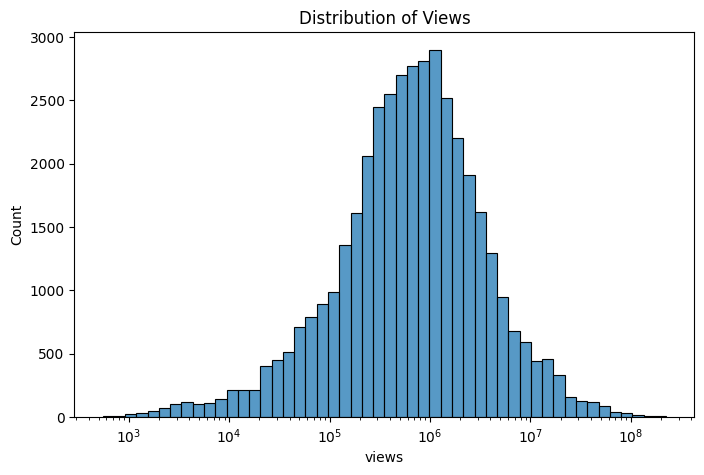

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['views'], bins=50, log_scale=True)
plt.title("Distribution of Views")
plt.show()

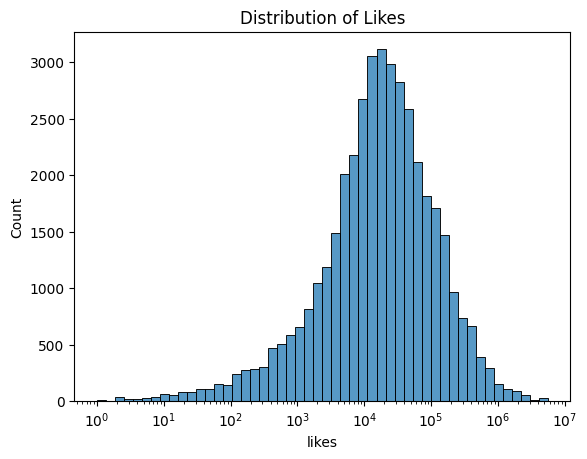

In [62]:
sns.histplot(df['likes'], bins=50, log_scale=True)
plt.title("Distribution of Likes")
plt.show()

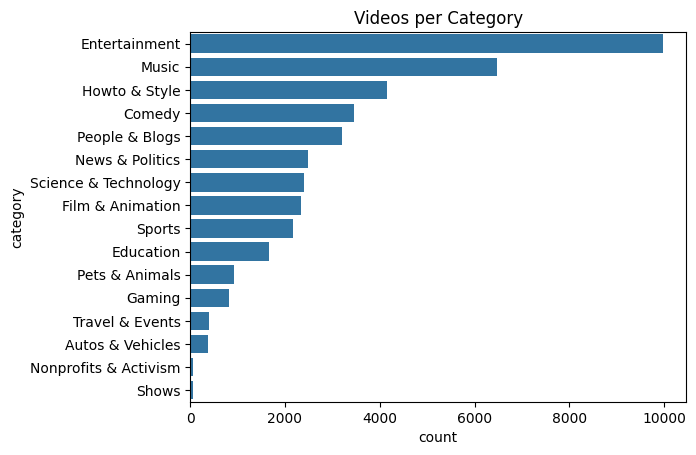

In [63]:
import sys
import os
sys.path.append(os.path.abspath('..'))  # go up one level to project root

from data_prep import get_cat_map, load_and_clean

df = load_and_clean()
cat_map = get_cat_map()
df['category'] = df['category_id'].map(cat_map)
df['category'].value_counts()

sns.countplot(y='category', data=df, order=df['category'].value_counts().index)
plt.title("Videos per Category")
plt.show()

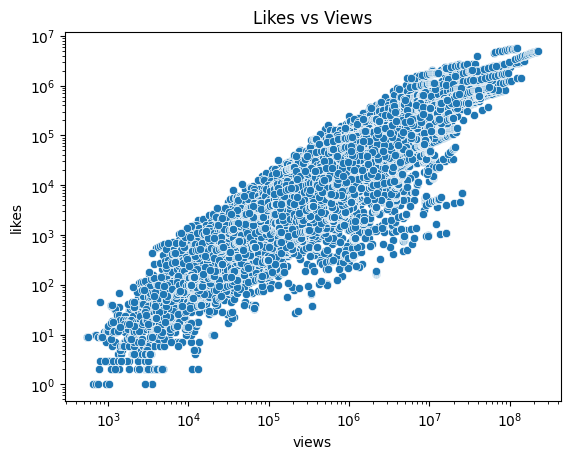

In [64]:
sns.scatterplot(x='views', y='likes', data=df)
plt.xscale('log')
plt.yscale('log')
plt.title("Likes vs Views")
plt.show()

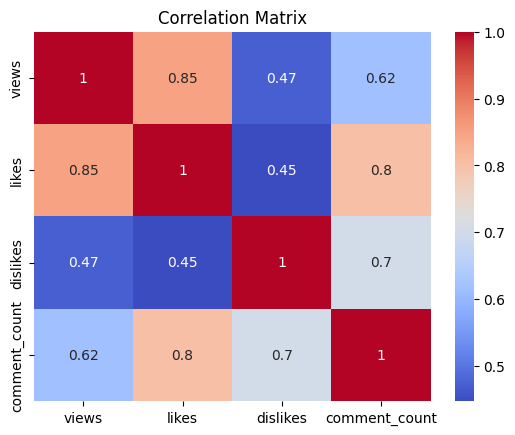

In [65]:
sns.heatmap(
    df[['views','likes','dislikes','comment_count']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

In [66]:
df.groupby('category')['views'].mean().sort_values(ascending=False)

category
Music                    6.201003e+06
Film & Animation         3.106250e+06
Nonprofits & Activism    2.963884e+06
Gaming                   2.620831e+06
Entertainment            2.067883e+06
Sports                   2.025969e+06
People & Blogs           1.531835e+06
Comedy                   1.480308e+06
Science & Technology     1.452627e+06
Autos & Vehicles         1.355965e+06
Howto & Style            9.837301e+05
Shows                    9.035273e+05
Travel & Events          8.546196e+05
Pets & Animals           8.311435e+05
Education                7.129408e+05
News & Politics          5.925877e+05
Name: views, dtype: float64

In [67]:

# Basic engagement metric (OK for EDA)
df['engagement_rate'] = (df['likes'] + df['comment_count']) / df['views']
df.groupby('publish_hour')['engagement_rate'].mean()

# For each publish_hour (0-23), the engagement rate (likes + comments / views)
# is shown. For exmample, videos posted at hour 13 (1:00 pm) have an engagement
# rate of 3.32%. 

publish_hour
0     0.039720
1     0.038410
2     0.032052
3     0.032582
4     0.031456
5     0.041534
6     0.025943
7     0.028752
8     0.029275
9     0.036184
10    0.027563
11    0.032770
12    0.031681
13    0.033227
14    0.035823
15    0.039604
16    0.040981
17    0.040031
18    0.041499
19    0.048023
20    0.042792
21    0.044719
22    0.044605
23    0.045760
Name: engagement_rate, dtype: float64

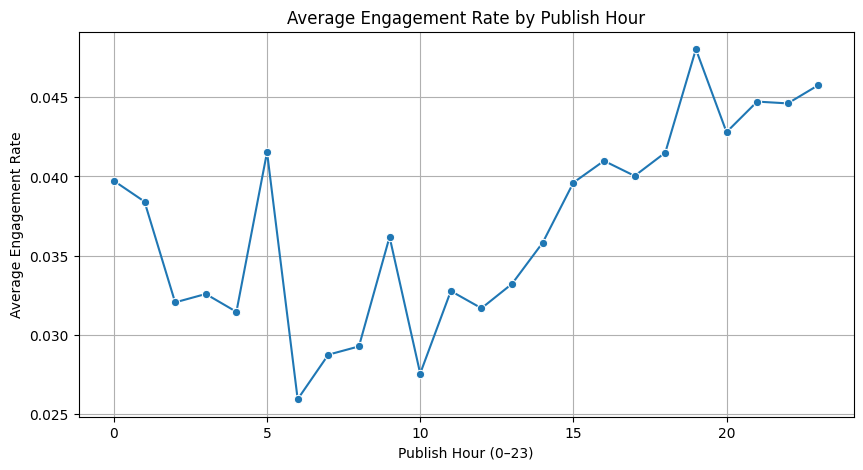

In [68]:
hourly_engagement = df.groupby('publish_hour')['engagement_rate'].mean()
plt.figure(figsize=(10,5))
sns.lineplot(x=hourly_engagement.index, y=hourly_engagement.values, marker='o')
plt.xlabel("Publish Hour (0–23)")
plt.ylabel("Average Engagement Rate")
plt.title("Average Engagement Rate by Publish Hour")
plt.grid(True)
plt.show()

In [72]:
# Remove duplicates by video_id, keeping the row with the highest views
df_unique = df.sort_values('views', ascending=False).drop_duplicates(subset='video_id', keep='first')

# Top 10 most viewed unique videos
top10_videos = df_unique.head(10)
top10_videos[['video_id', 'title', 'views', 'engagement_rate', 'category']]


,video_id,title,views,engagement_rate,category
38547,VYOjWnS4cMY,Childish Gambino - This Is America (Official V...,225211923,0.024602,Music
6181,FlsCjmMhFmw,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,149376127,0.026137,Entertainment
34708,ffxKSjUwKdU,Ariana Grande - No Tears Left To Cry,148689896,0.022436,Music
34888,zEf423kYfqk,"Becky G, Natti Natasha - Sin Pijama (Official ...",139334502,0.010833,Music
38273,7C2z4GqqS5E,BTS (방탄소년단) 'FAKE LOVE' Official MV,123010920,0.055625,Music
34747,M4ZoCHID9GI,The Weeknd - Call Out My Name (Official Video),122544931,0.012100,Music
2587,TyHvyGVs42U,"Luis Fonsi, Demi Lovato - Échame La Culpa",102012605,0.024613,Music
40869,xTlNMmZKwpA,"Cardi B, Bad Bunny & J Balvin - I Like It [Off...",94254507,0.020347,Music
4997,6ZfuNTqbHE8,Marvel Studios' Avengers: Infinity War Officia...,91933007,0.032373,Entertainment
25947,-BQJo3vK8O8,Maluma - El Préstamo (Official Video),87264467,0.009756,Music
